# Iris Dataset - Random Forest Hyperparameter Tuning
This notebook demonstrates loading the **Iris dataset**, tuning a **Random Forest Classifier** using both `GridSearchCV` and `RandomizedSearchCV`, evaluating performance, and comparing results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Preprocess Data

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("Feature Names:", X.columns.tolist())
print("Target Classes:", iris.target_names)

Train set shape: (120, 4)
Test set shape: (30, 4)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: ['setosa' 'versicolor' 'virginica']


## 2. GridSearchCV tuning

In [3]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [10, 40, 100, 150],
    'max_depth': [2, 5, 8, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf_grid = grid_search.best_estimator_
y_pred_grid = best_rf_grid.predict(X_test_scaled)
grid_accuracy = accuracy_score(y_test, y_pred_grid)

print(f"GridSearch Best Params: {grid_search.best_params_}")
print(f"GridSearch Test Accuracy: {grid_accuracy:.4f}")

GridSearch Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 40}
GridSearch Test Accuracy: 0.9667


## 3. RandomizedSearchCV tuning

In [4]:
rf_rand = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [10, 50, 100, 150, 200],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

rand_search = RandomizedSearchCV(
    rf_rand, param_distributions=param_dist, n_iter=20, cv=5, 
    scoring='accuracy', random_state=42, n_jobs=-1
)
rand_search.fit(X_train_scaled, y_train)

best_rf_rand = rand_search.best_estimator_
y_pred_rand = best_rf_rand.predict(X_test_scaled)
rand_accuracy = accuracy_score(y_test, y_pred_rand)

print(f"RandomizedSearch Best Params: {rand_search.best_params_}")
print(f"RandomizedSearch Test Accuracy: {rand_accuracy:.4f}")

RandomizedSearch Best Params: {'n_estimators': 10, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_depth': 3, 'criterion': 'gini'}
RandomizedSearch Test Accuracy: 0.9333


## 4. Validation Curves (Accuracy/Loss vs n_estimators)

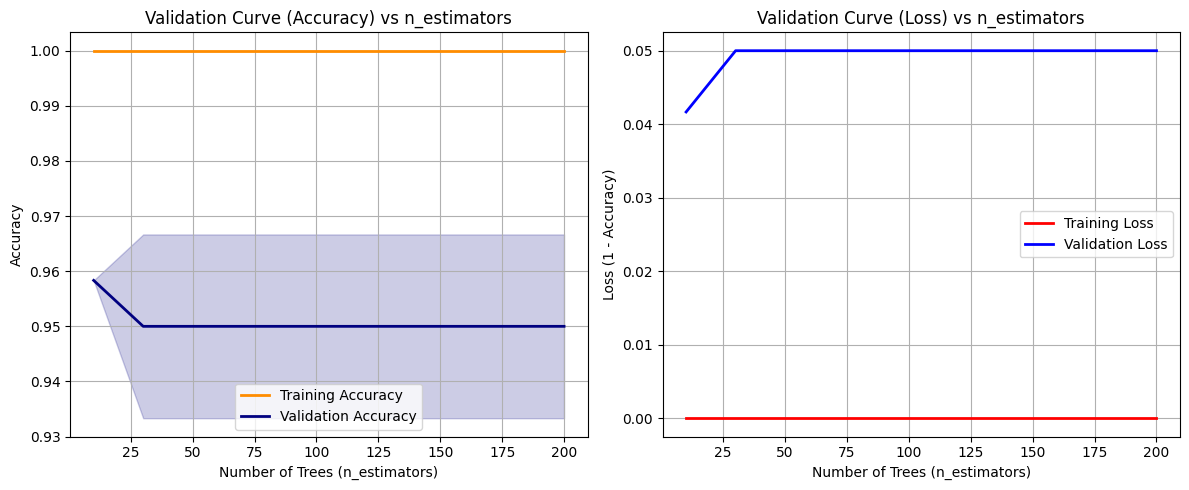

In [5]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

param_range = [10, 30, 50, 100, 150, 200]
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train_scaled, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

train_loss_mean = 1.0 - train_scores_mean
test_loss_mean = 1.0 - test_scores_mean

plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(param_range, train_scores_mean, label="Training Accuracy", color="darkorange", lw=2)
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="darkorange")
plt.plot(param_range, test_scores_mean, label="Validation Accuracy", color="navy", lw=2)
plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="navy")
plt.title("Validation Curve (Accuracy) vs n_estimators")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(loc="best")

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(param_range, train_loss_mean, label="Training Loss", color="red", lw=2)
plt.plot(param_range, test_loss_mean, label="Validation Loss", color="blue", lw=2)
plt.title("Validation Curve (Loss) vs n_estimators")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Loss (1 - Accuracy)")
plt.grid(True)
plt.legend(loc="best")

plt.tight_layout()
plt.savefig('iris_validation_curves.png')
plt.show()

## 5. Evaluation and Comparison

        Search Method                                        Best Params  \
0        GridSearchCV  {'criterion': 'gini', 'max_depth': 5, 'min_sam...   
1  RandomizedSearchCV  {'n_estimators': 10, 'min_samples_split': 15, ...   

   Test Accuracy  
0       0.966667  
1       0.933333  


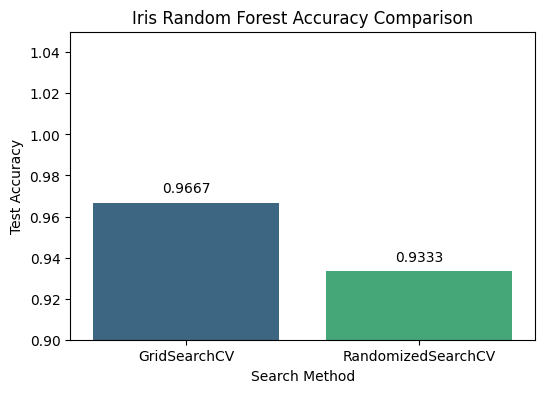

In [6]:
results = {
    'Search Method': ['GridSearchCV', 'RandomizedSearchCV'],
    'Best Params': [str(grid_search.best_params_), str(rand_search.best_params_)],
    'Test Accuracy': [grid_accuracy, rand_accuracy]
}
df_results = pd.DataFrame(results)
print(df_results)

# Plotting Comparison
plt.figure(figsize=(6, 4))
sns.barplot(x='Search Method', y='Test Accuracy', data=df_results, palette='viridis')
plt.title('Iris Random Forest Accuracy Comparison')
plt.ylim(0.9, 1.05)
for index, row in df_results.iterrows():
    plt.text(index, row['Test Accuracy'] + 0.005, f"{row['Test Accuracy']:.4f}", color='black', ha="center")
plt.savefig('iris_rf_comparison.png')
plt.show()